# Vérification du terme source de décroissance radioactive

In [ ]:
from trustutils import run

run.introduction("Yannick Gorsse")

## Introduction 
 Validation made by : Yannick Gorsse



 Report generated 17/12/2025

### Description

Le domaine d'application visé est la modélisation de l'évolution des précurseurs de neutrons retardés dans un calcul couplé avec un code de neutronique. En particulier, les précurseurs sont transportés dans les réacteurs à sels fondus. La distribution spatiale de la concentration en précurseurs (séparés en groupes associés à une constante de décroissance radioactive différente) est résolue entièrement dans TRUST via une équation de converction diffusion de la concentration : $$\partial_t c + \nabla\cdot( u c) - \nabla\cdot\left(D_\text{eff}\nabla c\right) = {\color{red}{-\lambda c}} + \text{Prod}$$

Ce terme peut être implémenté via source_constituant et champ_fonc_fonction, mais ne pourra pas être implicité, s'exposant ainsi à de potentielles instabilités.
Le terme source radioactive_decay permet d'impliciter ce terme. Pour vérifier l'implémentation on néglige les termes de convection et de diffusion : $$\partial_t c = {\color{red}{-\lambda c}} + \text{Prod}$$
La solution de cette équation est : $$c = \frac{\text{Prod}}{\lambda} (e^{-\lambda t} - 1)$$

In [40]:
run.TRUST_parameters("1.8.0")

### TRUST parameters 
 * Version TRUST: 1.8.0
 * Binary used: /Volumes/codes/tnk/TRUST_NK_opt (built in directory /Volumes/codes/trust/Validation/Rapports_automatiques/Verification/Verification_codage/radioactive_decay/build)

In [ ]:
from trustutils import run

type_srcs = {"decay" : "radioactive_decay 2 0.01 2.0"} #, "constant" : "source_Constituant champ_fonc_fonction pb_fluide concentration 2 -0.01*val -2.0*val"}

option_mesh = {"VEFPreP1B" : "tetraedriser_homogene_compact dom_fluide",
                "VDF" : "",
                "PolyMAC_P0" : "Polyedriser dom_fluide",
                "PolyVEF_P0" : "Polyedriser dom_fluide",
                "PolyMAC_P0P1NC" : "Polyedriser dom_fluide"}

diss = ["VEFPreP1B", "PolyMAC_P0P1NC", "PolyMAC_P0"]
diss = ["PolyVEF_P0"]
dts = ["0.001", "0.1", "1"]

run.reset()
for dis in diss:
    for name_src, type_src in type_srcs.items():
        for dt in dts:
            run.addCaseFromTemplate("jdd.data", f"{dis}/{name_src}/dt{dt}", {"decay" : type_src, "dt" : dt, "dis" : dis, "action_maillage" : option_mesh[dis]})

run.printCases()
run.runCases()

### Test cases 
* PolyVEF_P0/decay/dt0.001/jdd.data 
* PolyVEF_P0/decay/dt0.1/jdd.data 
* PolyVEF_P0/decay/dt1/jdd.data 


Running ...
  => A total of 3 cases were (successfully) run in 4.7s.


## Comparaisons a une solution de reference 
### Comparaison

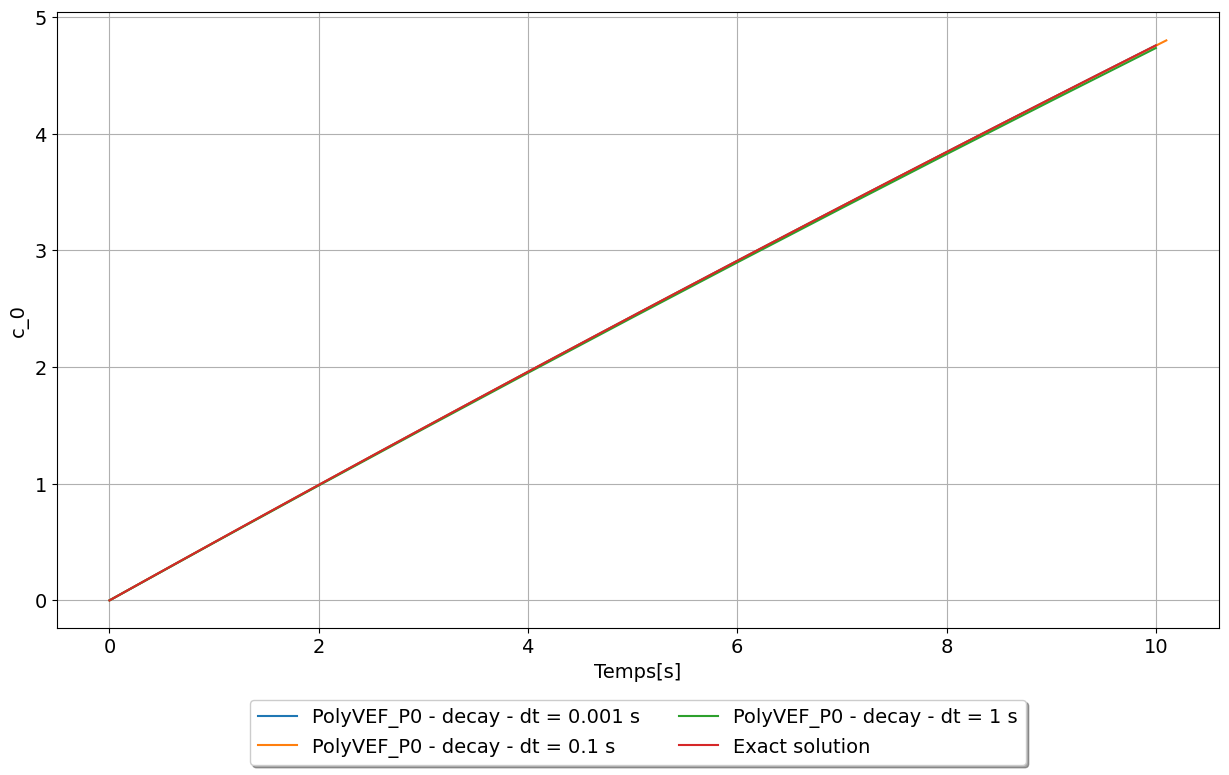

In [ ]:
from trustutils import plot
import numpy as np

a = plot.Graph("",size=[15,8])

for dis in diss:
    for name_src, type_src in type_srcs.items():
        for dt in dts:
            a.addPoint(f"{dis}/{name_src}/dt{dt}/jdd_C.son", label=f"{dis} - {name_src} - dt = {dt} s")

x = np.linspace(0,10,100)
y=-0.5/0.01*(np.exp(-0.01*x)-1)
a.add(x,y,label="Exact solution", marker="--", color="black")

a.label("Temps[s]","c_0")
a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=2)

a.visu()

## Comparaison

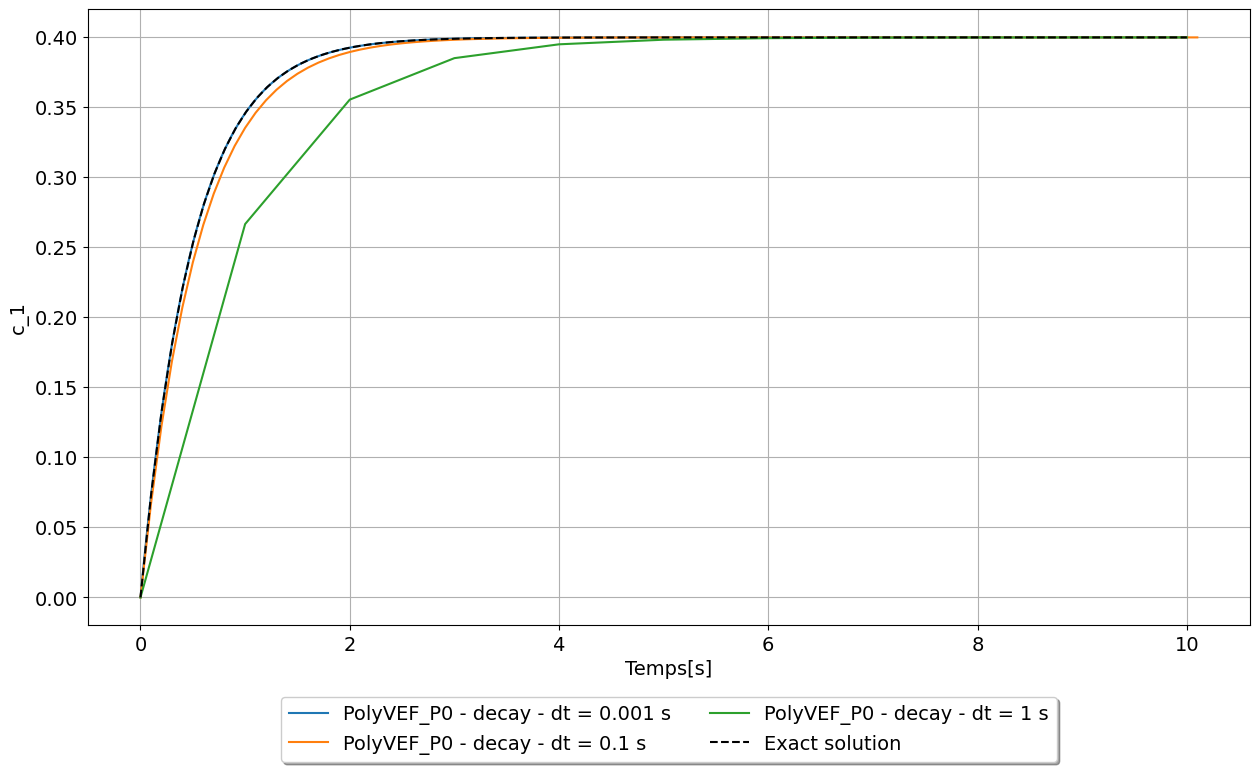

In [ ]:
from trustutils import plot
import numpy as np

a = plot.Graph("",size=[15,8])

for dis in diss:
    for name_src, type_src in type_srcs.items():
        for dt in dts:
            a.addPoint(f"{dis}/{name_src}/dt{dt}/jdd_C.son", compo=1, label=f"{dis} - {name_src} - dt = {dt} s")

x = np.linspace(0,10,100)
y=-0.8/2.*(np.exp(-2.0*x)-1)
a.add(x,y,label="Exact solution", marker="--", color="black")

a.label("Temps[s]","c_1")
a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=2)

a.visu()

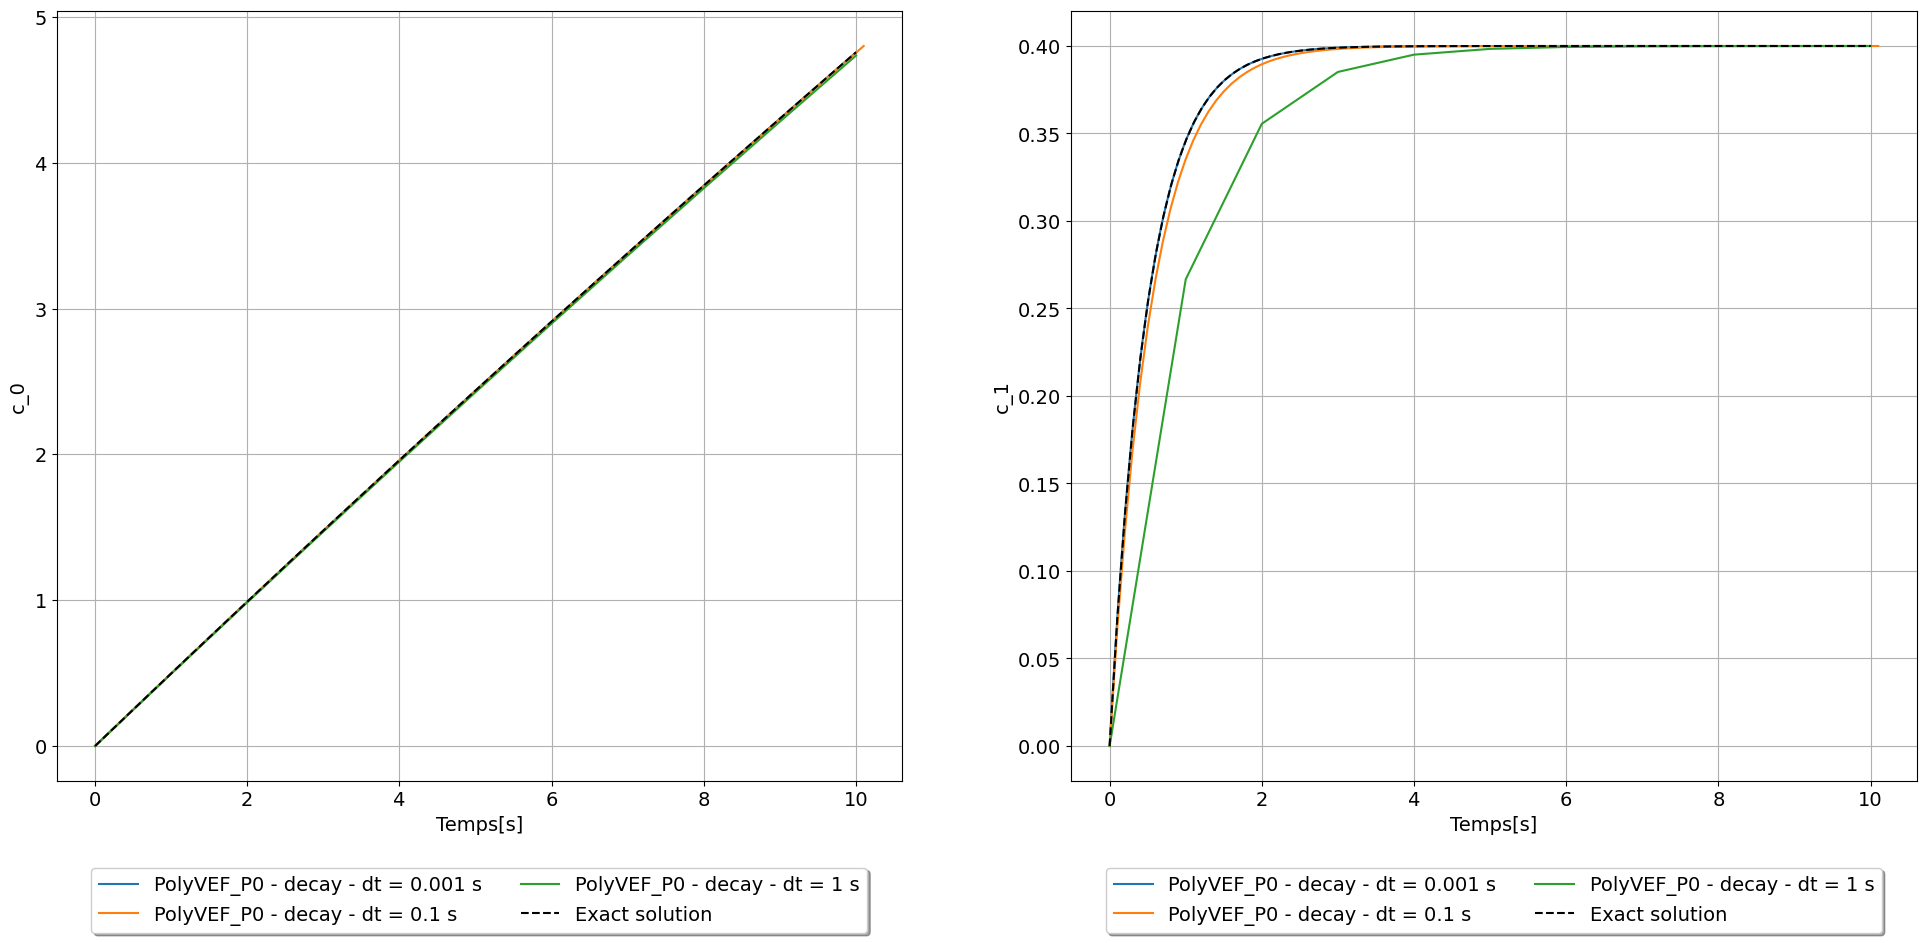

In [ ]:
from trustutils import plot
import numpy as np

a = plot.Graph("",nY=2)
for compo in [0, 1]:
    a.addPlot(compo)
    for dis in diss:
        for name_src, type_src in type_srcs.items():
            for dt in dts:
                a.addPoint(f"{dis}/{name_src}/dt{dt}/jdd_C.son", compo=compo, label=f"{dis} - {name_src} - dt = {dt} s")

    x = np.linspace(0,10,100)
    if compo == 0:
        y=-0.5/0.01*(np.exp(-0.01*x)-1)
    else:
        y=-0.8/2.*(np.exp(-2.0*x)-1)
    a.add(x,y,label="Exact solution", marker="--", color="black")

    a.label("Temps[s]",f"c_{compo}")
    a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
            fancybox=True, shadow=True, ncol=2)
